# Students Academic Performance Analytics
A high-impact, exploratory data analysis using the 'rocket' color palette and deep profiling.


In [595]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 11
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')


In [596]:
df = pd.read_csv(r'Dataset/StudentsPerformance.csv')

df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('/', '_')

print(f'Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns')
print('\n--- Data Sample ---')
print(df.head().to_string(index=False))


Dataset Shape: 1000 rows, 8 columns

--- Data Sample ---
gender race_ethnicity parental_level_of_education        lunch test_preparation_course  math_score  reading_score  writing_score
female        group B           bachelor's degree     standard                    none          72             72             74
female        group C                some college     standard               completed          69             90             88
female        group B             master's degree     standard                    none          90             95             93
  male        group A          associate's degree free/reduced                    none          47             57             44
  male        group C                some college     standard                    none          76             78             75


In [597]:
df['average_score'] = df[['math_score', 'reading_score', 'writing_score']].mean(axis=1)

df['performance_tier'] = pd.qcut(
    df['average_score'],
    q=4,
    labels=['Struggling (Bottom 25%)', 'Average (25-50%)', 'Good (50-75%)', 'Top Performers (Top 25%)']
)

categorical_features = [
    'gender',
    'race_ethnicity',
    'parental_level_of_education',
    'lunch',
    'test_preparation_course',
]

print('--- Metric Summary ---')
print(df[['math_score', 'reading_score', 'writing_score', 'average_score']].describe().round(2).to_string())


--- Metric Summary ---
       math_score  reading_score  writing_score  average_score
count     1000.00        1000.00        1000.00        1000.00
mean        66.09          69.17          68.05          67.77
std         15.16          14.60          15.20          14.26
min          0.00          17.00          10.00           9.00
25%         57.00          59.00          57.75          58.33
50%         66.00          70.00          69.00          68.33
75%         77.00          79.00          79.00          77.67
max        100.00         100.00         100.00         100.00


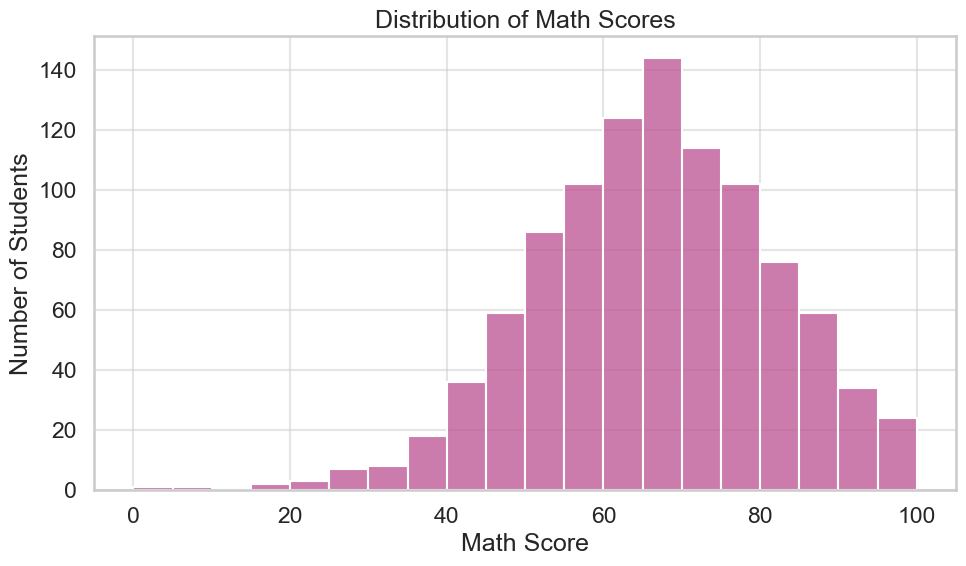

In [598]:
plt.figure(figsize=(10, 6))
sns.histplot(df['math_score'], bins=20, color='#bc5090')
plt.title('Distribution of Math Scores')
plt.xlabel('Math Score')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.savefig('output.png', dpi=300, bbox_inches='tight')
plt.show()


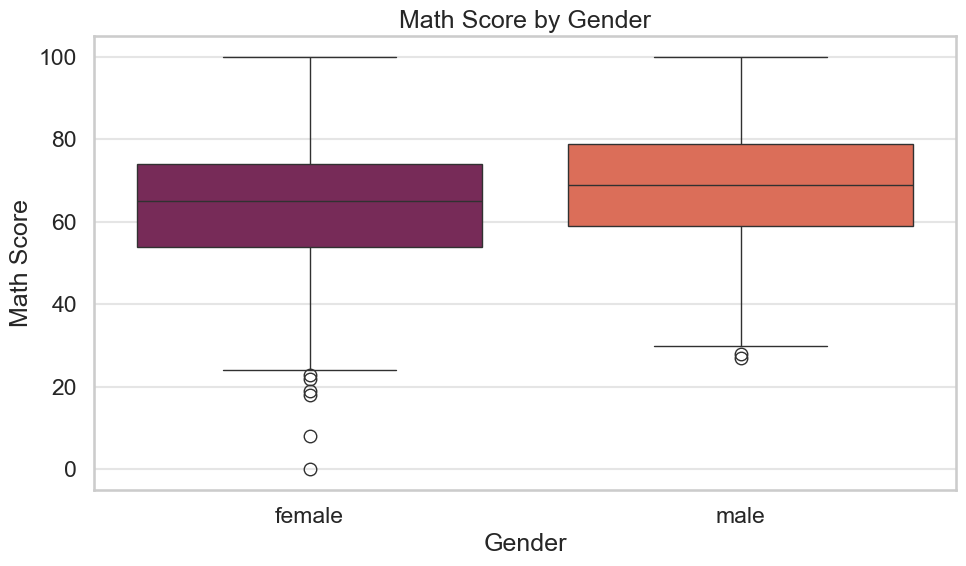

In [599]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='gender', y='math_score', palette='rocket')
plt.title('Math Score by Gender')
plt.xlabel('Gender')
plt.ylabel('Math Score')
plt.tight_layout()
plt.savefig('output2.png', dpi=300, bbox_inches='tight')
plt.show()


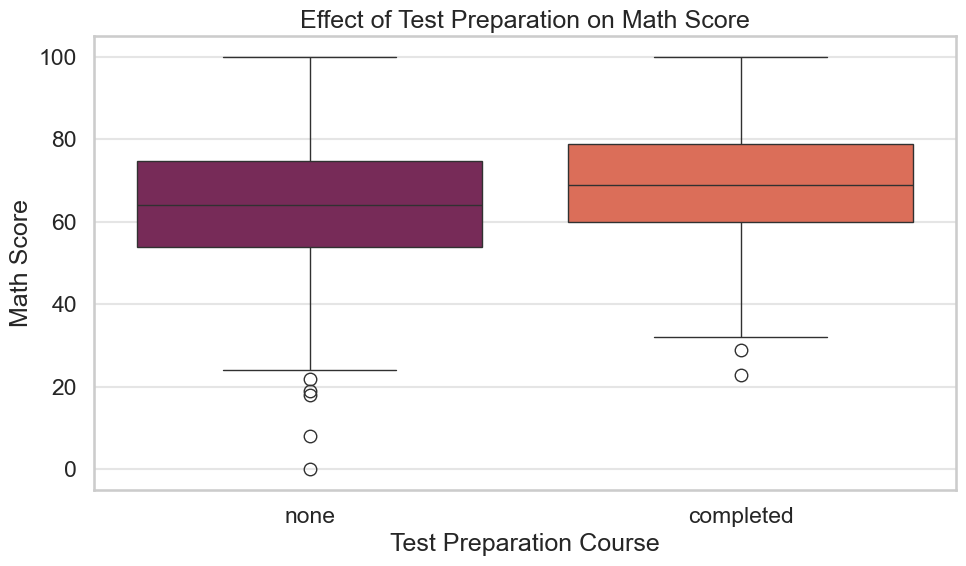

In [600]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='test_preparation_course', y='math_score', palette='rocket')
plt.title('Effect of Test Preparation on Math Score')
plt.xlabel('Test Preparation Course')
plt.ylabel('Math Score')
plt.tight_layout()
plt.savefig('output3.png', dpi=300, bbox_inches='tight')
plt.show()


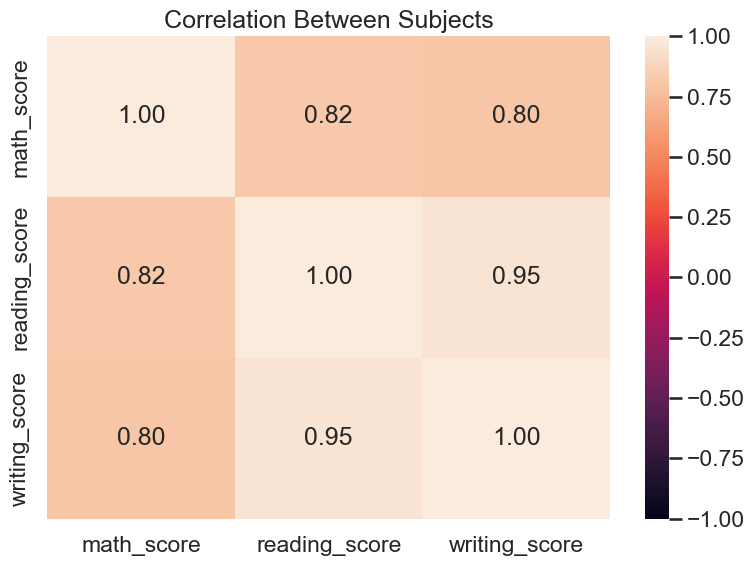

In [601]:
corr = df[['math_score', 'reading_score', 'writing_score']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='rocket', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Between Subjects')
plt.tight_layout()
plt.savefig('output4.png', dpi=300, bbox_inches='tight')
plt.show()


## All charts and diagrams in the project
These cells regenerate every plot and diagram used in the analysis and slide deck, one chart per cell.


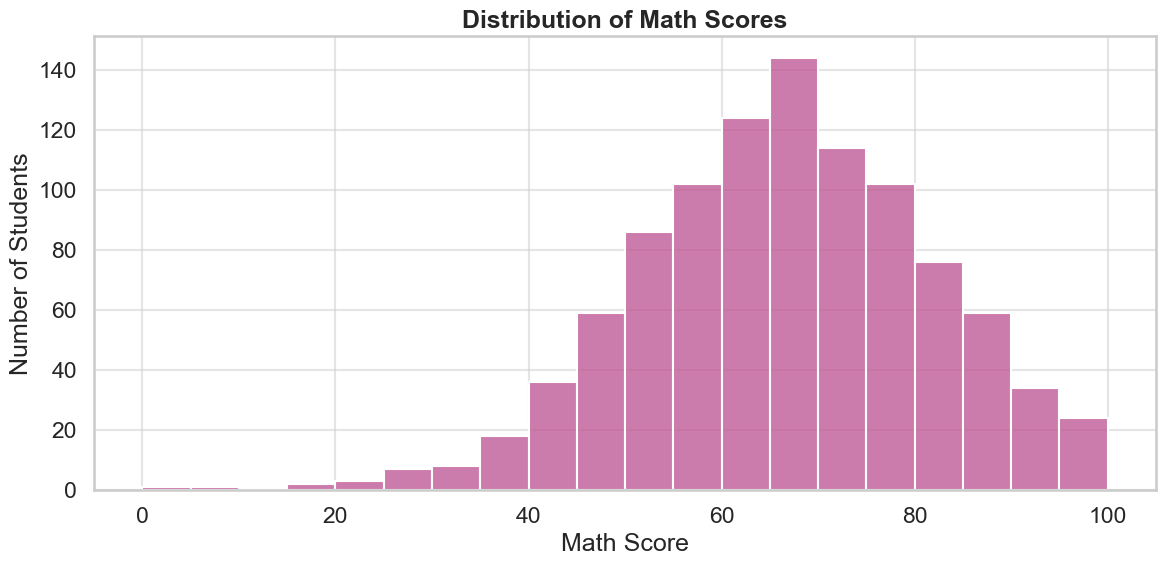

In [602]:
plt.figure(figsize=(12, 6))
sns.histplot(df['math_score'], bins=20, color='#bc5090')
plt.title('Distribution of Math Scores', fontweight='bold')
plt.xlabel('Math Score')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.savefig('output_math_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


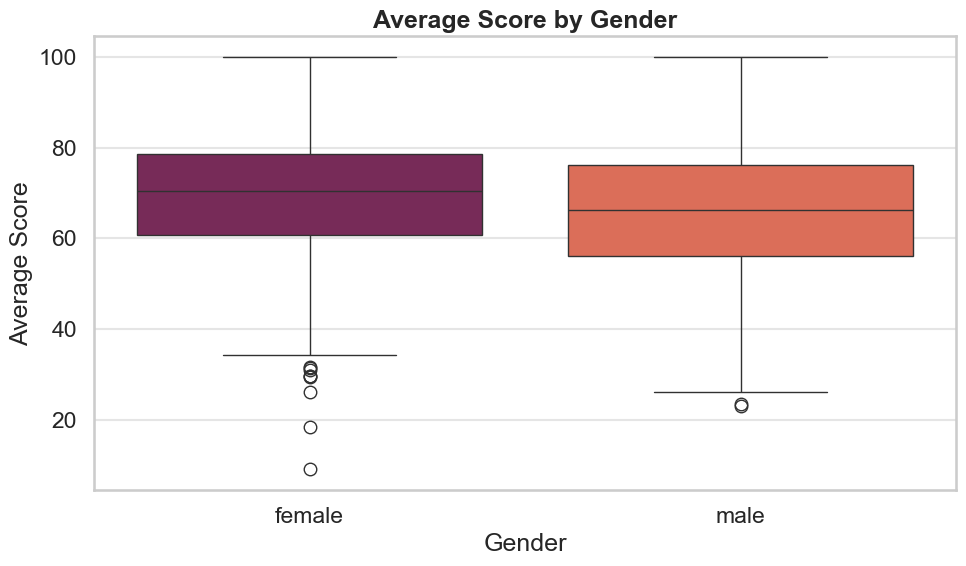

In [603]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='gender', y='average_score', palette='rocket')
plt.title('Average Score by Gender', fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Average Score')
plt.tight_layout()
plt.savefig('output_gender_score.png', dpi=300, bbox_inches='tight')
plt.show()


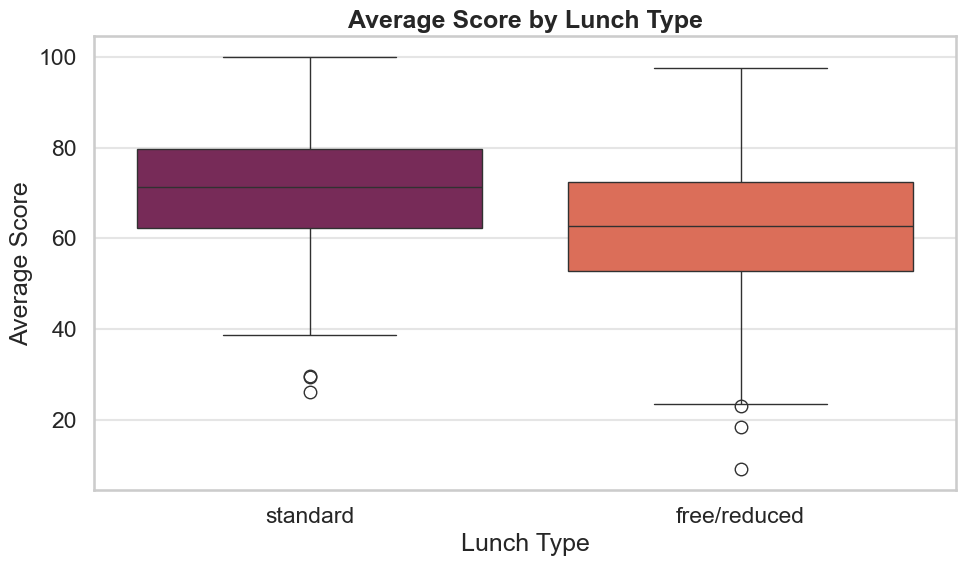

In [604]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='lunch', y='average_score', palette='rocket')
plt.title('Average Score by Lunch Type', fontweight='bold')
plt.xlabel('Lunch Type')
plt.ylabel('Average Score')
plt.tight_layout()
plt.savefig('output_lunch_score.png', dpi=300, bbox_inches='tight')
plt.show()


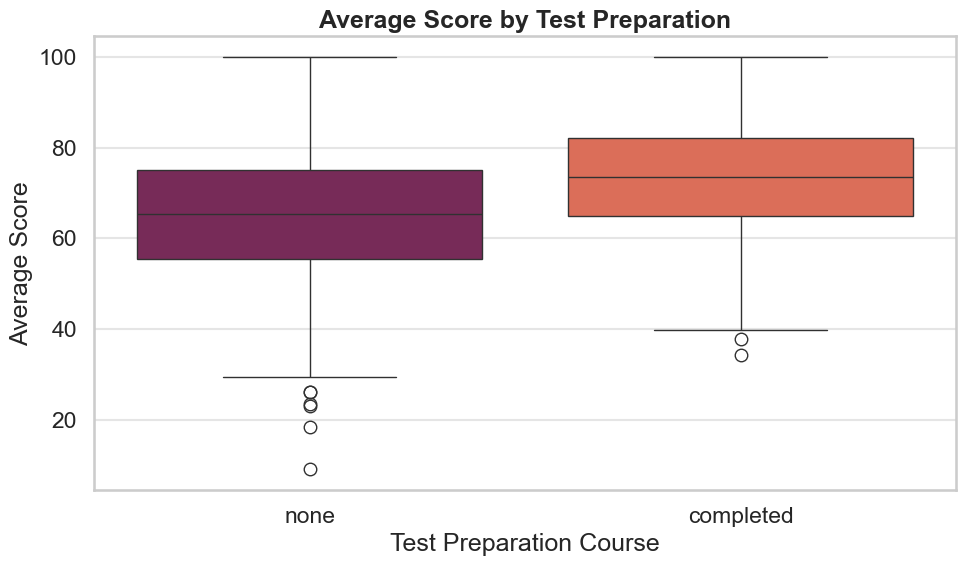

In [605]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='test_preparation_course', y='average_score', palette='rocket')
plt.title('Average Score by Test Preparation', fontweight='bold')
plt.xlabel('Test Preparation Course')
plt.ylabel('Average Score')
plt.tight_layout()
plt.savefig('output_test_prep_score.png', dpi=300, bbox_inches='tight')
plt.show()


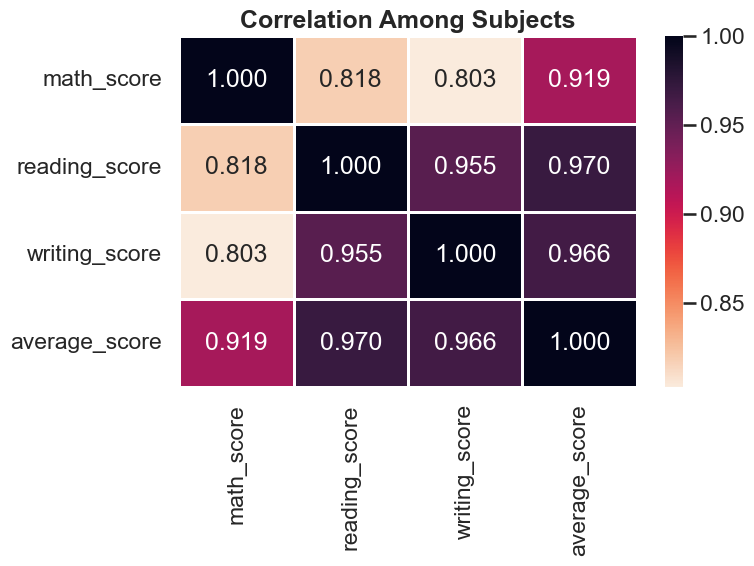

In [606]:
corr = df[['math_score', 'reading_score', 'writing_score', 'average_score']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='rocket_r', fmt='.3f', linewidths=2)
plt.title('Correlation Among Subjects', fontweight='bold')
plt.tight_layout()
plt.savefig('output_subject_corr.png', dpi=300, bbox_inches='tight')
plt.show()


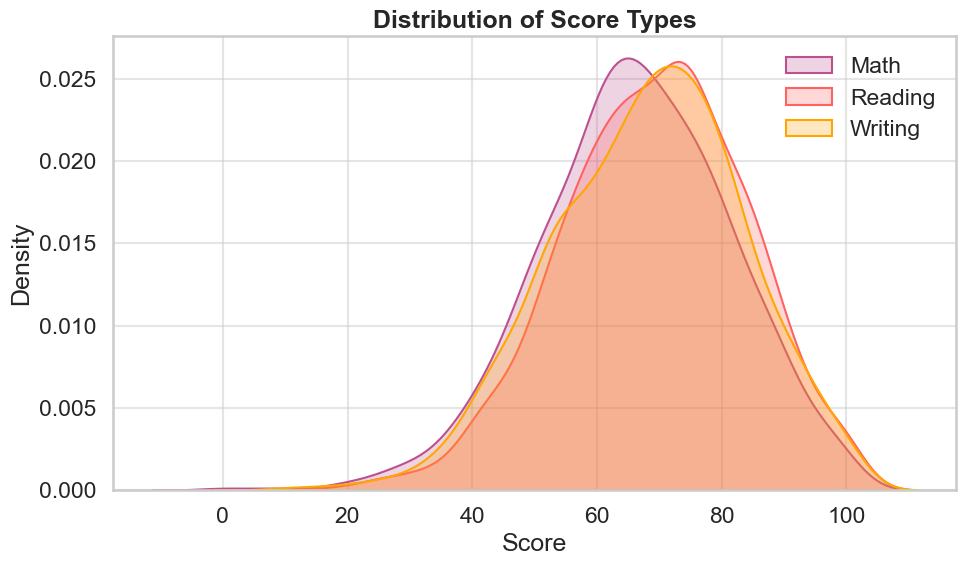

In [607]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='math_score', fill=True, color='#bc5090', label='Math')
sns.kdeplot(data=df, x='reading_score', fill=True, color='#ff6361', label='Reading')
sns.kdeplot(data=df, x='writing_score', fill=True, color='#ffa600', label='Writing')
plt.title('Distribution of Score Types', fontweight='bold')
plt.xlabel('Score')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig('output_density.png', dpi=300, bbox_inches='tight')
plt.show()


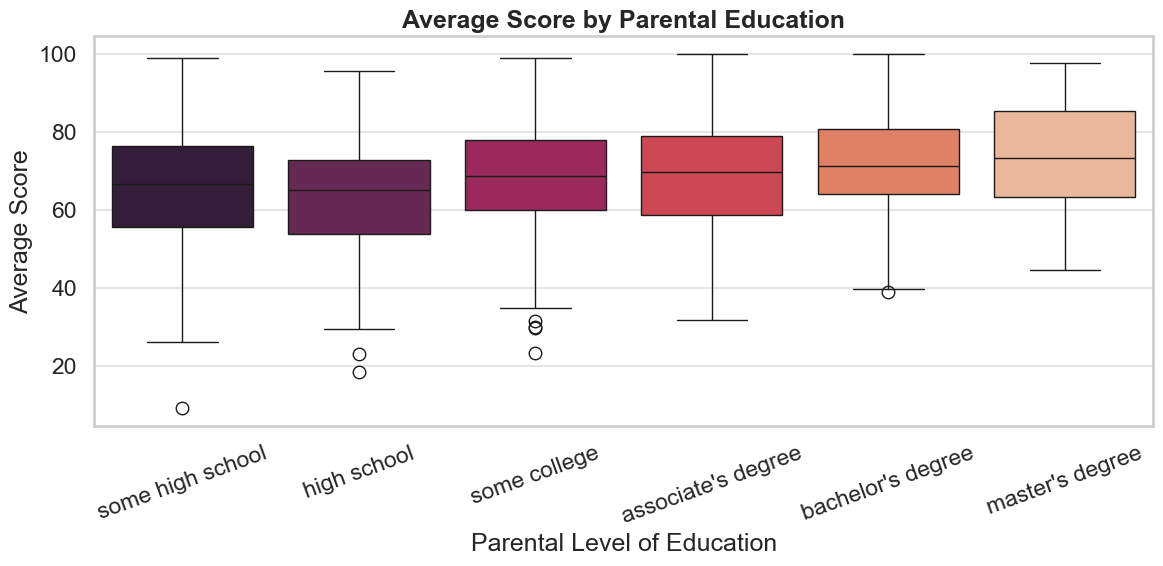

In [608]:
order = ['some high school', 'high school', 'some college', "associate's degree", "bachelor's degree", "master's degree"]
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='parental_level_of_education', y='average_score', palette='rocket', order=order)
plt.title('Average Score by Parental Education', fontweight='bold')
plt.xlabel('Parental Level of Education')
plt.ylabel('Average Score')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('output_parental_education_scores.png', dpi=300, bbox_inches='tight')
plt.show()


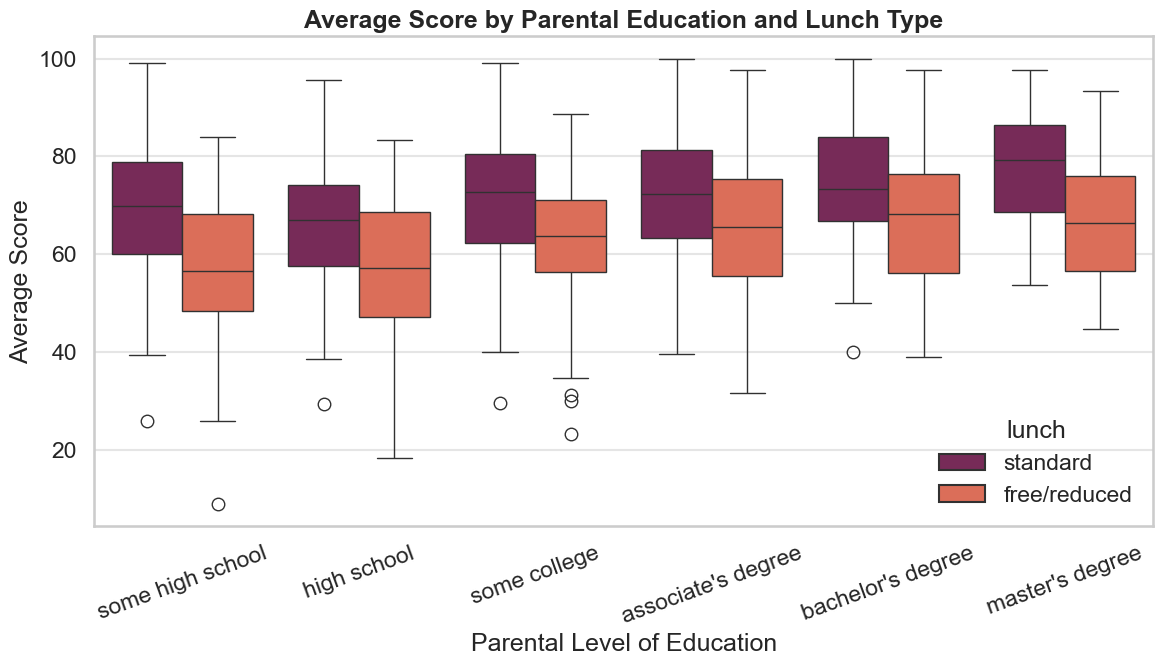

In [609]:
order = ['some high school', 'high school', 'some college', "associate's degree", "bachelor's degree", "master's degree"]
plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x='parental_level_of_education', y='average_score', hue='lunch', palette='rocket', order=order, dodge=True)
plt.title('Average Score by Parental Education and Lunch Type', fontweight='bold')
plt.xlabel('Parental Level of Education')
plt.ylabel('Average Score')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('output_parental_education_lunch.png', dpi=300, bbox_inches='tight')
plt.show()


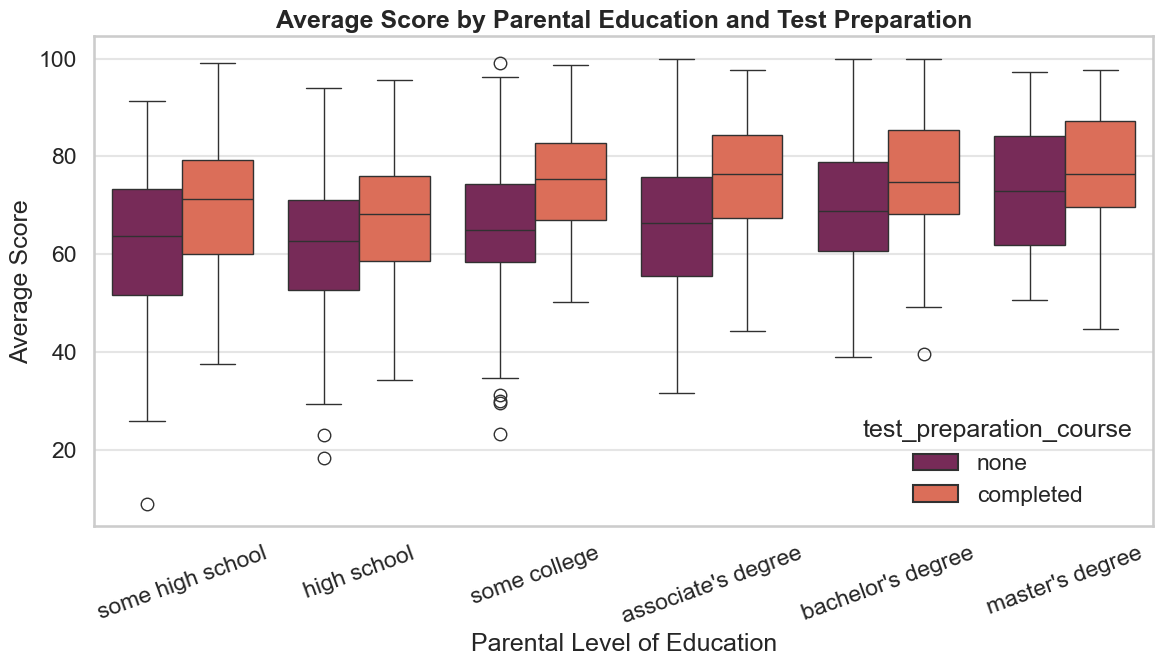

In [610]:
order = ['some high school', 'high school', 'some college', "associate's degree", "bachelor's degree", "master's degree"]
plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x='parental_level_of_education', y='average_score', hue='test_preparation_course', palette='rocket', order=order, dodge=True)
plt.title('Average Score by Parental Education and Test Preparation', fontweight='bold')
plt.xlabel('Parental Level of Education')
plt.ylabel('Average Score')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('output_parental_education_prep.png', dpi=300, bbox_inches='tight')
plt.show()


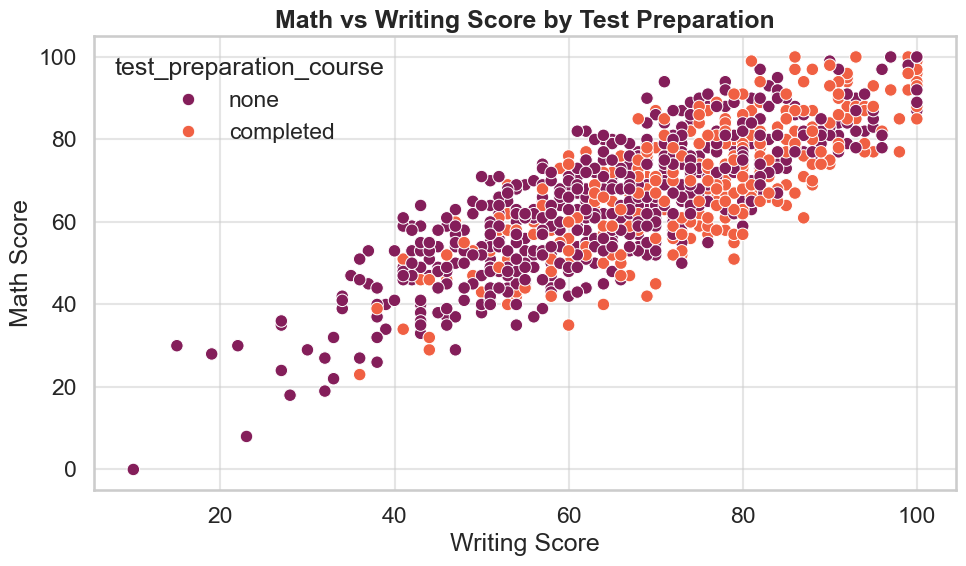

In [611]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='writing_score', y='math_score', hue='test_preparation_course', palette='rocket')
plt.title('Math vs Writing Score by Test Preparation', fontweight='bold')
plt.xlabel('Writing Score')
plt.ylabel('Math Score')
plt.tight_layout()
plt.savefig('output_math_writing_prep.png', dpi=300, bbox_inches='tight')
plt.show()


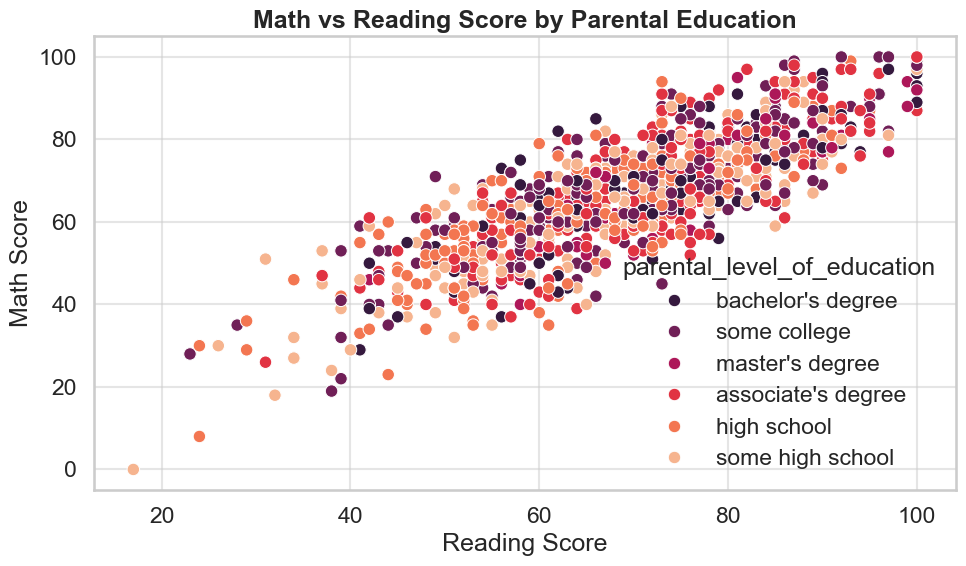

In [612]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='reading_score', y='math_score', hue='parental_level_of_education', palette='rocket')
plt.title('Math vs Reading Score by Parental Education', fontweight='bold')
plt.xlabel('Reading Score')
plt.ylabel('Math Score')
plt.tight_layout()
plt.savefig('output_math_reading_parental_education.png', dpi=300, bbox_inches='tight')
plt.show()


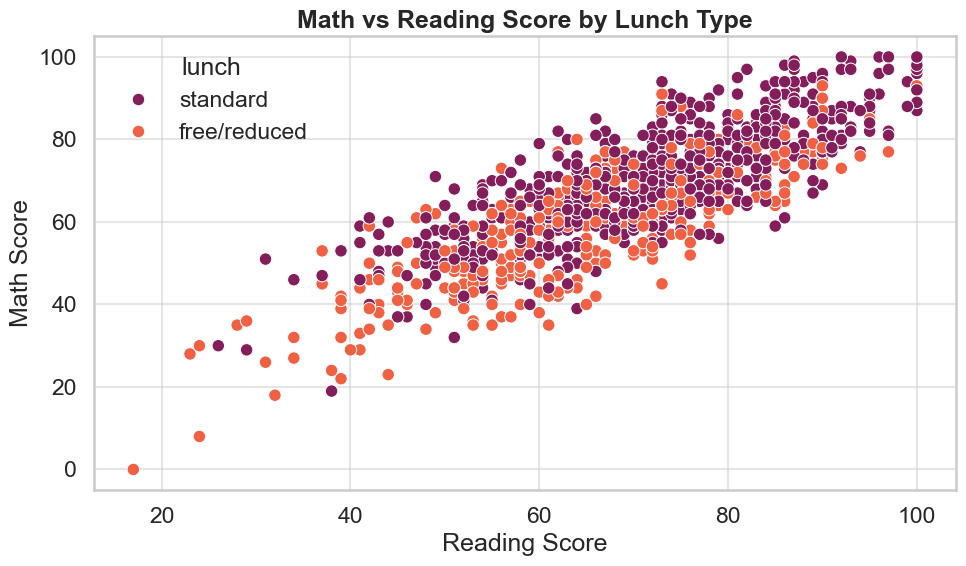

In [613]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='reading_score', y='math_score', hue='lunch', palette='rocket')
plt.title('Math vs Reading Score by Lunch Type', fontweight='bold')
plt.xlabel('Reading Score')
plt.ylabel('Math Score')
plt.tight_layout()
plt.savefig('output_math_reading_lunch.png', dpi=300, bbox_inches='tight')
plt.show()


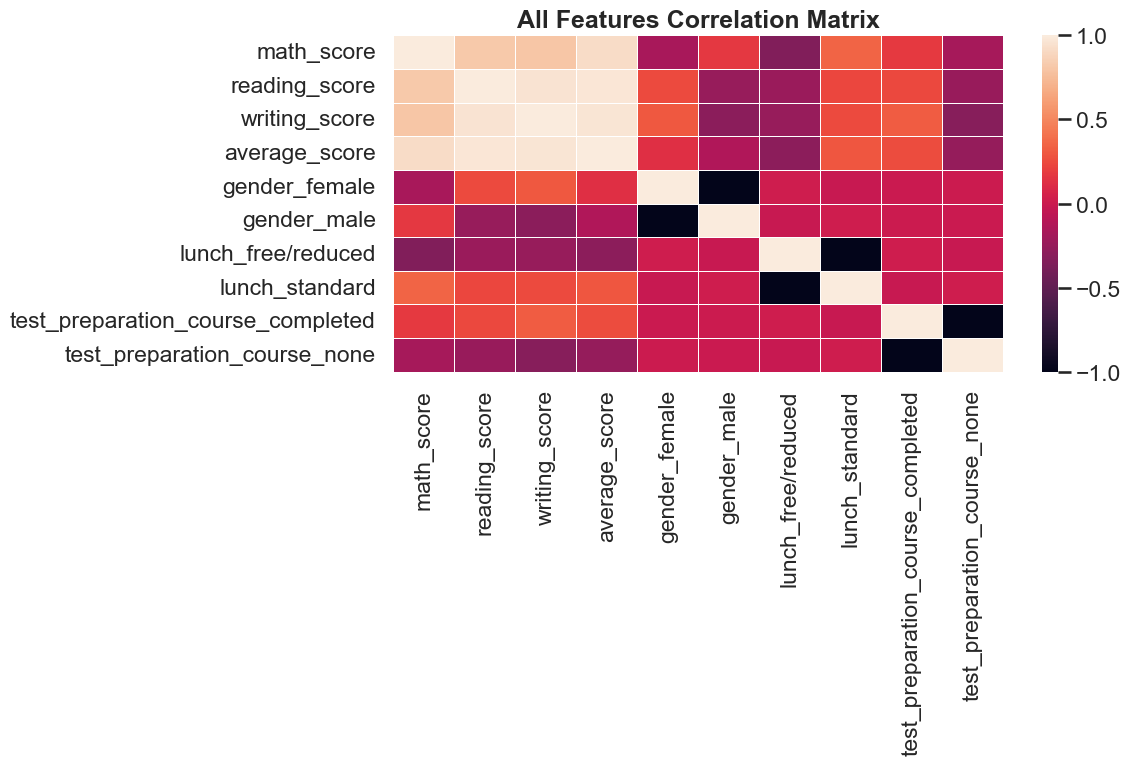

In [614]:
numeric = df[['math_score','reading_score','writing_score','average_score']].copy()
for col in ['gender','lunch','test_preparation_course']:
    numeric = pd.concat([numeric, pd.get_dummies(df[col], prefix=col, dtype=float)], axis=1)
plt.figure(figsize=(12, 8))
sns.heatmap(numeric.corr(), annot=False, cmap='rocket', linewidths=0.5)
plt.title('All Features Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('output_all_features_corr.png', dpi=300, bbox_inches='tight')
plt.show()


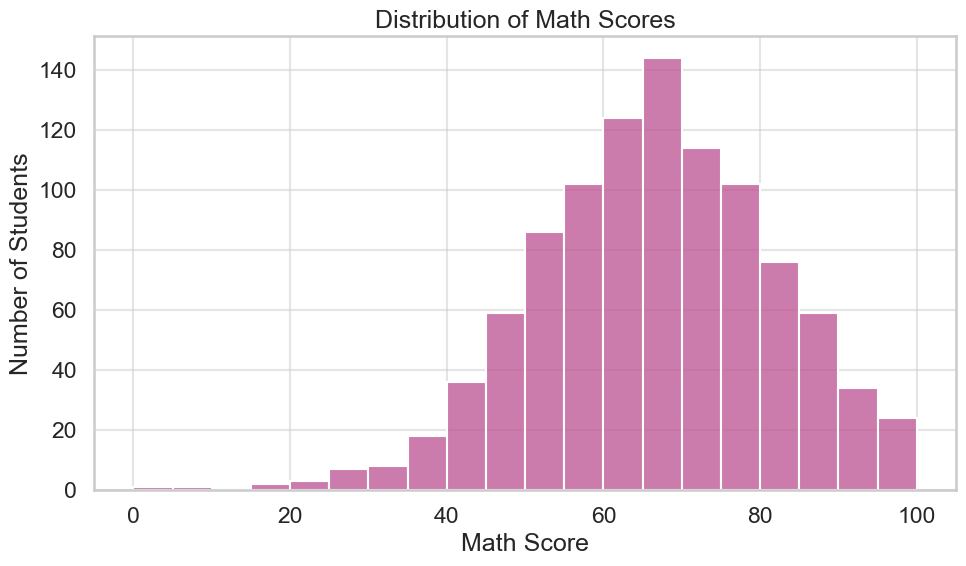

In [615]:
plt.figure(figsize=(10, 6))
sns.histplot(df['math_score'], bins=20, color='#bc5090')
plt.title('Distribution of Math Scores')
plt.xlabel('Math Score')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.savefig('output.png', dpi=300, bbox_inches='tight')
plt.show()


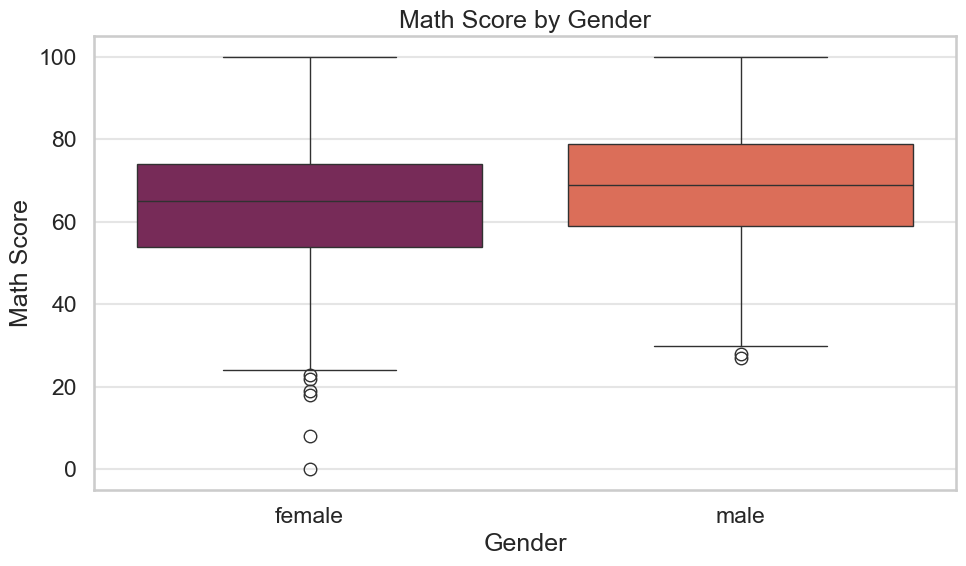

In [616]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='gender', y='math_score', palette='rocket')
plt.title('Math Score by Gender')
plt.xlabel('Gender')
plt.ylabel('Math Score')
plt.tight_layout()
plt.savefig('output2.png', dpi=300, bbox_inches='tight')
plt.show()


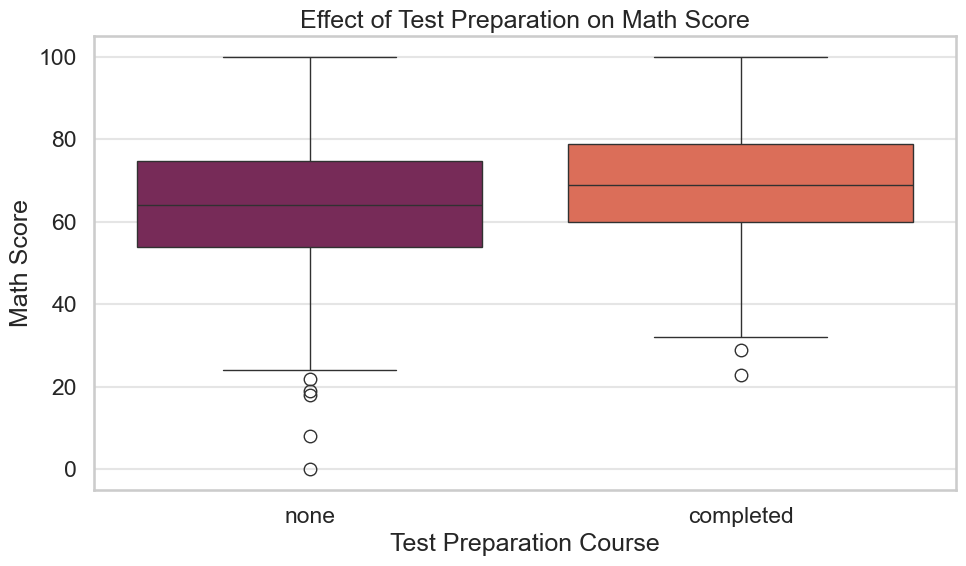

In [617]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='test_preparation_course', y='math_score', palette='rocket')
plt.title('Effect of Test Preparation on Math Score')
plt.xlabel('Test Preparation Course')
plt.ylabel('Math Score')
plt.tight_layout()
plt.savefig('output3.png', dpi=300, bbox_inches='tight')
plt.show()


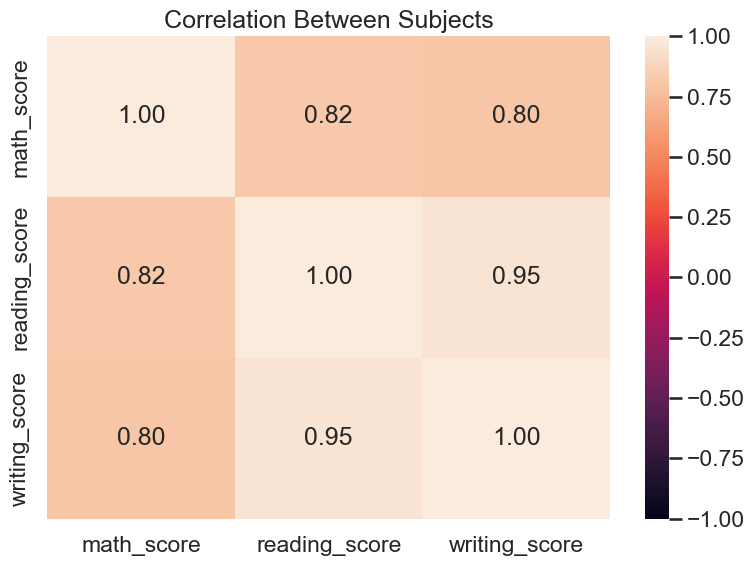

In [618]:
corr = df[['math_score', 'reading_score', 'writing_score']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='rocket', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Between Subjects')
plt.tight_layout()
plt.savefig('output4.png', dpi=300, bbox_inches='tight')
plt.show()
